# **Project Goals**

The goal of the project would be as follows:

1: Write your own code (not an existing repo on the internet) that performs single shot ptychography using structured illumination as demonstrated in the papers by Levitan et al.

2: answer the following question:

a. What happens if the illumination (=probe) field has zero crossings? Is this a problem for the method? Do zero crossing result in non-measured points?

b. suppose the method is simulated using 2x2 upsampling (that is, 2x2 probe pixels determine the average phase in a 1x1 super-pixel inside the object). Is it required that there is a relative phase shift between the 2x2 pixels inside the probe? Or can the modulation be amplitude-only (that is no phase shift, but an intensity variation)

c. What is the minimum amount of upsampling needed?

d. Is there a class of illumination functions for which the method fails?

e. Try implementing regularization to the method. Please include L1, L2, and Total variation regularization.

# **Project Ptychography**

Illumination: A grid of partially overlapping beams, each beam approaches the sample from different angles. 

Reconstruction: Randomized probe imaging algorithm. 

General strategy: Divide the intensity pattern into a collection of individual, smaller diffraction patterns. The smaller patterns are centered on an individual beam and tagged with a corresponding translation at the same plane.

X-ray problem: Difficult to generate a grid of identical beams with sufficient angular separation and uniform intensities. Grating equation: $d(
\sin\theta_m) = m\lambda$. Small wavelength leads to small grating period.

Feature: It recovers both the probe and the object, so the probe is not needed to be known. But the division of the detector limits resolution by limiting the NA

Method used in the single-shot article:

A purely iterative algorithm for single-shot ptychography which uses a pre-calibrated probe and operates on full diffraction patterns without partitioning them into a ptychography dataset.

This method overcomes limitations of the general strategy that in cases where the object contains high frequency components, the scattering from neighboring beams does overlap and interfere, causing reconstructions to perform poorly.

The forward model for this algorithm:

$$I = \sum_{n=1}^{N} \left| \mathcal{F} \left\{ P_n \cdot \mathcal{F}^{-1} \left\{ \mathcal{U} \cdot \mathcal{F} \left\{\exp(i T)\right\} \right\} \right\} \right|^2$$

$P_n$ is the discrete representation= of the nth mode of the pre-calibrated probe. $\mathcal{U} is a zero padding operator, and $T$ is a low-resolution representation of the object's transmission function

Zero-padding $\mathcal{U}$ is a band-limiting constraint that stablizes the inverse problem.

$T$ is constraint to be purely real to apply an additional phase-only constraint on the object. Allowing $T$ to be complex-valued can remove the phase-only constraint. The final object function is defined as:

$$ O = \exp(iT)$$

The first step of the model is to upsample the low-resolution object $O$ by padding it with zeros in Fourier space

In [104]:
import h5py
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import jit

In [105]:
def probe_generation():

    pass

In [106]:
def down_sampling_fre(obj, f=2):
    '''
        down sampling the obj with factor f in Fourier space
    '''
    m, n = obj.shape
    obj_fre = jnp.fft.fftshift(jnp.fft.fft2(obj))
    m_d, n_d = m // f, n // f  # downsampling size
    m_d = int(m_d)
    n_d = int(n_d)

    m_center, n_center = m // 2, n // 2  # original center
    m_d_half, n_d_half = n_d // 2, m_d // 2

    #index of cropped area
    m_start = m_center - m_d_half
    m_end = m_start + m_d
    n_start = n_center - n_d_half
    n_end = n_start + n_d

    obj_fre_cropped = obj_fre[m_start:m_end, n_start:n_end]

    obj_downSampled = jnp.fft.ifft2(jnp.fft.ifftshift(obj_fre_cropped))
    return obj_downSampled


def down_sampling_spa(obj,f=2):
    '''
        down sampling the obj with factor f in spatial domain
        block averaging is employed, average amplitude and phase
    '''
    m, n = obj.shape

    # crop obj to ensure integer times with the factor
    m_crop = (m // f) * f
    n_crop = (n // f) * f
    obj_cropped = obj[:m_crop, :n_crop]

    reshaped = obj_cropped.reshape(m_crop // f, f, n_crop // f, f)
    obj_downSampled = reshaped.mean(axis=(1, 3))

    return obj_downSampled

In [107]:
def pad_array(array, pad_array):
    pad_factortb = jnp.abs((jnp.shape(pad_array)[0] - jnp.shape(array)[0])) // 2
    pad_factorrl = jnp.abs((jnp.shape(pad_array)[1] - jnp.shape(array)[1])) // 2
    paded_array = jnp.pad(array, ((pad_factortb, pad_factortb),(pad_factorrl, pad_factorrl)))
    return paded_array

In [108]:
def forward_model(obj, probe, f=1.5):
    '''
        the forward model generates the update diffraction field from the down sampled obj
        in this simulation assumes only one probe 
    '''
    obj_downSampled = down_sampling_fre(obj, f)
    obj_fre = jnp.fft.fftshift(jnp.fft.fft2(obj_downSampled))
    obj_frepad = pad_array(obj_fre, probe[0, :, :])
    obj_pad = jnp.fft.ifft2(jnp.fft.ifftshift(obj_frepad))
    update_diff_pattern0 = (jnp.abs(
        jnp.fft.fftshift(jnp.fft.fft2((probe[0]) * jnp.exp(obj_pad)))))**2  #
    update_diff_pattern1 = (jnp.abs(
        jnp.fft.fftshift(jnp.fft.fft2((probe[1, :, :]) * jnp.exp(obj_pad)))))**2 #
    # update_diff_pattern = update_diff_pattern0 * 0.756 + update_diff_pattern1 * 0.244
    update_diff_pattern = update_diff_pattern0

    # return (jnp.abs(update_diff_pattern))**2
    return update_diff_pattern

## **Reconstruction**

To perform a reconstruction, we start with an initial guess of the project function and use a forward model to simulate the corresponding diffraction pattern. 

Next, we calculate the normalized mean squared error between the measured diffraction amplitudes and a simulated diffraction pattern including a known detector background:

$$ L = \frac{1}{\sum_{ij}I_{ij}} \sum_{ij}\left( \sqrt{|\tilde{E_{ij}}|^2 + B_{ij}} - \sqrt{I_{ij}}\right)^2$$

From the equation above, we can write it in Python:

In [109]:
import jax.numpy as jnp
from chex import assert_equal_shape
from jax import jit

def loss_function(simulated: jnp.ndarray, background: jnp.ndarray, measured: jnp.ndarray) -> float:
    '''
    Calculates the normalized mean squared error (L) for the given simulated diffraction amplitudes E, detector background B, and the measured diffraction pattern I.

    Args: 
        simulated (jnp.ndarray): The simulated diffraction pattern (Intensity) calculated from a forward model
        backgroud (jnp.ndarray): The detector background (Intensity)
        I (jnp.ndarray): The measured diffraction pattern (Intensity)
    
    Return:
        float: The normalized mean squared error (L) 
    '''
    # Assert that the three arrays have the same shape
    assert_equal_shape([simulated, background, measured])

    # Calculate the factor to normalize the error
    factor = 1.0 / (jnp.sum(measured) + 1e-10)

    # Calculate the simulated diffraction amplitudes
    simulated_amp = jnp.sqrt(jnp.abs(simulated)**2 + background)

    # Calculate the measured diffraction amplitudes
    measured_amp = jnp.sqrt(measured)

    # Calculate the normalized mean squared error
    loss = factor * jnp.sum((simulated_amp - measured_amp) ** 2)

    return loss

Example usage:

In [110]:
simulated = jnp.array([[1.0, 2.0], [3.0, 4.0]])  # Simulated amplitudes (complex or real)
background = jnp.array([[0.1, 0.1], [0.1, 0.1]])   # Background
measured = jnp.array([[1.5, 4.5], [9.5, 16.5]])   # Measured intensities

print("loss =", loss_function(simulated, background, measured))

loss = 0.0014692659


We then use automatic differentiation to calculate the Wirtinger derivative of the loss function with respect to the object guess $T$:

$$ \frac{\delta L}{\delta T} = \frac{\delta L}{\delta |E_{ij}|^2} \frac{\delta |E_{ij}|^2}{\delta T}$$

In [111]:
from jax import grad

def derivative_loss_function_wrt_obj(obj: jnp.ndarray, probe: jnp.ndarray, measured: jnp.ndarray, background: jnp.ndarray) -> jnp.ndarray:
    '''
    Calculates the Wirtinger derivative of the loss function with respect to the object guess obj.

    Args:
        obj (jnp.ndarray): The object guess (complex or real)

    Return:
        jnp.ndarray: The derivative of the loss function with respect to the object guess obj
    '''
    def loss_wrt_obj(o):
        simulated = forward_model(o, probe)
        return loss_function(simulated, background, measured)
    return grad(loss_wrt_obj)(obj)

Then, we feed those derivatives into an update for the object guess $T_{guess}$ using the Adam algorithm. This process is repeated iteratively until the object converges.

Adam is short for Adaptive Moment Estimation. It's a popular optimization algorithm used in machine learning to train models like neural networks. It's a type of stochastic gradient descent (SGD) that adapts the learning rate for each parameter.

Adam maintains two moving averages for each parameter $\theta$:

1.First Moment (Mean): An estimate of the gradient, similar to momentum, denoted as:
$$ m_{t} = \beta_{1}m_{t-1} + (1 - \beta_1)g_t $$
where $g_t$ is the gradient at time step t, and $\beta_1$ is typically set to 0.9.

2.Second Moment (Variance): An estimate of the squared gradient, similar to RMSprop, denoted as:
$$ v_t = \beta_2v_{t-1} + (1-\beta_2)g_t^2$$
where $\beta_2$ is typically set to 0.999.

The bias-corrected first and second moments are: 
$$ \hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$
$$ \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

The parameter update rule is then:

$$ \theta_{t+1} = \theta_t - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

 where $\alpha$ is the learning rate, $\epsilon$ is a small constant to prevent division by zero, and $t$ is the current iteration.

In [112]:
import optax

def adam_optimization(init_obj: jnp.ndarray, measured: jnp.ndarray, background: jnp.ndarray, probe: jnp.ndarray, alpha: float, num_iterations: int) -> jnp.ndarray:
    '''
    Optimizes an object using the Adam optimizer to minimize the loss between simulated and measured data.
    
    Args:
        init_obj (jnp.ndarray): Initial guess of the object to be optimized.
        measured (jnp.ndarray): Measured data (ground truth) used to compute the loss.
        background (jnp.ndarray): Background data included in the loss calculation.
        probe (jnp.ndarray): Probe array used in the forward model simulation.
        alpha (float): Initial learning rate for the Adam optimizer.
        num_iterations (int): Maximum number of optimization iterations.
    
    Returns:
        jnp.ndarray: Optimized object array after specified iterations or convergence.
    '''
    # Initialize the the Adam optimizer and the object state
    optimizer = optax.adam(alpha)
    opt_state = optimizer.init(init_obj)
    obj = init_obj
    
    # Initialize the best loss and plateau counter
    best_loss = float('inf') # Start with the maximum possible value
    plateau_counter = 0
    current_alpha = alpha

    # Run the optimization loop
    for _ in range(num_iterations):
        # Compute the gradients of the loss function with respect to the object guess
        grad_obj = derivative_loss_function_wrt_obj(obj, probe, measured, background)
        
        # Update the object guess using the Adam optimizer
        updates, opt_state = optimizer.update(grad_obj, opt_state, obj)
        obj = jnp.real(optax.apply_updates(obj, updates))
        
        # Calculate the loss using the updated object
        simulated = forward_model(obj, probe)
        loss = loss_function(simulated, background, measured)
        
        # Update the best loss and plateau counter
        if loss < best_loss:
            best_loss = loss
            plateau_counter = 0
        else:
            plateau_counter += 1
        
        # Adjust the learning rate if the loss has plateaued
        if plateau_counter >= 10:
            current_alpha *= 0.1
            print(f"Alpha reduced to {current_alpha}")
            optimizer = optax.adam(current_alpha)
            opt_state = optimizer.init(obj)
            plateau_counter = 0

        # Print the loss value every 50 iterations
        if _ % 50 == 0:
            print(f"Iteration: {_}, Loss: {loss}")
        
        # Check for convergence
        if loss < 1e-9 or alpha < 1e-4:
            print("Converged below threshold.")
            break
    return obj

In [113]:
def data_read(filepath=r'Papercode\cxi_files\e17965_1_00677.cxi'):
    with h5py.File(filepath, 'r') as f:
        data = f['entry_1/data_1/data'][:]
        data = jnp.mean(data,axis=0)
    return data

def background_read(filepath = r'Papercode\reconstructions\e17965_1_00677_ptycho_reconstruction.h5'):
    with h5py.File(filepath, 'r') as f:
        dataset = f['background']
        background = jnp.array(dataset[:])  # 读取整个数据集
        return background
    
def probe_read(filepath=r'Papercode\reconstructions\e17965_1_00678_ptycho_reconstruction.h5'):
    with h5py.File(filepath, 'r') as f:
        # print("Keys in the file:", list(f.keys()))
        dataset = f['probe']
        probe = jnp.array(dataset[:])  # 读取整个数据集
        # there are two probe modes
        return probe

In [114]:
probe = probe_read()

Simu obj

In [115]:
from PIL import Image
file = r'Canon-100Block.png'
image = Image.open(file)
img = jnp.array(image)
img_shape = jnp.shape(img)
img_crop = img[img_shape[0] // 2 - 624:img_shape[0] // 2,
               img_shape[1] // 2 - 624:img_shape[1] // 2]
print(img_crop)

[[  0   0 255 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 ...
 [  0   0   0 ...   0 255 255]
 [  0   0   0 ...   0   0 255]
 [  0   0   0 ...   0   0   0]]


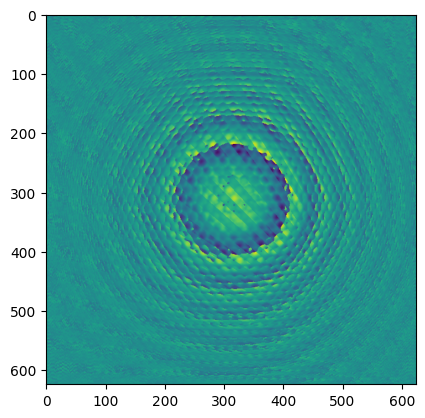

In [116]:
phase_obj = 1j * jnp.where(img_crop==255, 2*jnp.pi, jnp.pi)
probe_illu = jnp.sqrt(probe[0])
obj_field = probe_illu * phase_obj
plt.imshow(jnp.real(obj_field))

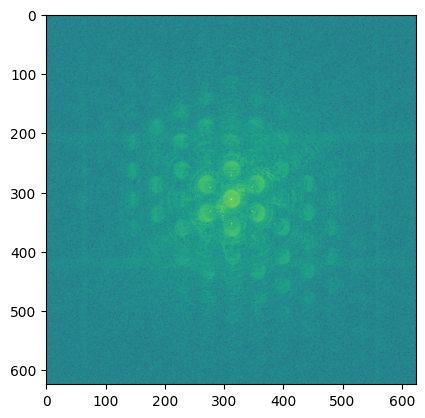

In [117]:
data = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(obj_field)))**2
plt.imshow(jnp.log(data+1))

In [118]:
bcg = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(probe[0])))**2

In [119]:
#import jax.random as jran
#key1 = jran.PRNGKey(2)
#bcg = jran.normal(key1, shape=(624, 624))

In [120]:
import jax.random as jran
#initilize
# initial_data = data * np.exp(1j * np.random.uniform(0, 2*np.pi, size=data.shape))
key = jran.PRNGKey(0)
key_real, key_imag = jran.split(key)
real_part = jran.normal(key_real, shape=jnp.shape(data))
# imag_part = jran.normal(key_imag, shape=jnp.shape(data))

# Assume that the initial guess is real
initial_obj_guess = real_part
obj = jnp.copy(initial_obj_guess)

Iteration: 0, Loss: 417152384.0
Iteration: 50, Loss: 59855.171875
Iteration: 100, Loss: 35527.0078125
Iteration: 150, Loss: 27935.59765625
Iteration: 0, Loss: 4516.37939453125
Iteration: 50, Loss: 0.8605040311813354
Iteration: 100, Loss: 0.5943573713302612
Iteration: 150, Loss: 0.49632206559181213
Iteration: 200, Loss: 0.43709835410118103
Iteration: 250, Loss: 0.39434123039245605
Iteration: 300, Loss: 0.36040788888931274
Iteration: 350, Loss: 0.3335493803024292
Iteration: 400, Loss: 0.3131254315376282
Iteration: 450, Loss: 0.29730674624443054
Iteration: 0, Loss: 0.3770449161529541
Alpha reduced to 0.04000000000000001
Iteration: 50, Loss: 0.14956927299499512
Iteration: 100, Loss: 0.09892021864652634
Iteration: 150, Loss: 0.07828725874423981
Iteration: 200, Loss: 0.06825453788042068
Iteration: 250, Loss: 0.06264223903417587
Iteration: 300, Loss: 0.05881701782345772
Iteration: 350, Loss: 0.05619103088974953
Iteration: 400, Loss: 0.05420130863785744
Iteration: 450, Loss: 0.0527007505297660

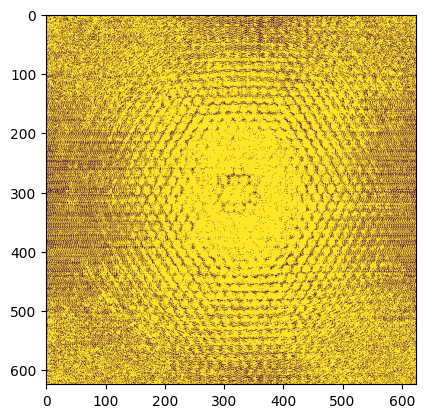

In [121]:
# Optimize the loss fucntion three times
update_obj = adam_optimization(init_obj = obj, measured = data, background=bcg, probe = probe, alpha = 0.4, num_iterations = 200)

update_obj_1 = adam_optimization(update_obj, data, bcg, probe, 0.4, 500)

update_obj_2 = adam_optimization(update_obj_1, data, bcg, probe, 0.4, 1000)

plt.imshow(jnp.angle(update_obj))